In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"..\datasets\Walmart_Sales.csv")
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [4]:
df.columns = df.columns.str.lower()

In [5]:
def f_to_c(x):
    return (x - 32) * 5 / 9

In [6]:
df["temperature"] = df["temperature"].map(f_to_c)

In [7]:
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y")

In [8]:
df.head()

,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment
0,1,2010-02-05,1643690.90,0,5.727778,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,3.616667,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,4.405556,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,8.127778,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,8.055556,2.625,211.350143,8.106


In [9]:
df["month"] = df["date"].dt.to_period("M")   
df["year"] = df["date"].dt.year
df["day_of_week"] = df["date"].dt.dayofweek
df["day_name"] = df["date"].dt.day_name()
df["day_of_month"] = df["date"].dt.day
df["month_num"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter
df["month_name"] = df["date"].dt.month_name()  

In [10]:
df

,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment,month,year,day_of_week,day_name,day_of_month,month_num,quarter,month_name
0,1,2010-02-05,1643690.90,0,5.727778,2.572,211.096358,8.106,2010-02,2010,4,Friday,5,2,1,February
1,1,2010-02-12,1641957.44,1,3.616667,2.548,211.242170,8.106,2010-02,2010,4,Friday,12,2,1,February
2,1,2010-02-19,1611968.17,0,4.405556,2.514,211.289143,8.106,2010-02,2010,4,Friday,19,2,1,February
3,1,2010-02-26,1409727.59,0,8.127778,2.561,211.319643,8.106,2010-02,2010,4,Friday,26,2,1,February
4,1,2010-03-05,1554806.68,0,8.055556,2.625,211.350143,8.106,2010-03,2010,4,Friday,5,3,1,March
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,18.266667,3.997,192.013558,8.684,2012-09,2012,4,Friday,28,9,3,September
6431,45,2012-10-05,733455.07,0,18.272222,3.985,192.170412,8.667,2012-10,2012,4,Friday,5,10,4,October
6432,45,2012-10-12,734464.36,0,12.483333,4.000,192.327265,8.667,2012-10,2012,4,Friday,12,10,4,October
6433,45,2012-10-19,718125.53,0,13.594444,3.969,192.330854,8.667,2012-10,2012,4,Friday,19,10,4,October


In [11]:
monthly_sales = df.groupby(["year", "month_num", "month_name"])["weekly_sales"].sum().reset_index()   
monthly_sales.rename(columns={"weekly_sales": "total_sales"}, inplace=True)
monthly_sales

,year,month_num,month_name,total_sales
0,2010,2,February,1.903330e+08
1,2010,3,March,1.819198e+08
2,2010,4,April,2.314124e+08
3,2010,5,May,1.867109e+08
4,2010,6,June,1.922462e+08
5,2010,7,July,2.325801e+08
6,2010,8,August,1.876401e+08
7,2010,9,September,1.772679e+08
8,2010,10,October,2.171618e+08
9,2010,11,November,2.028534e+08


In [12]:
pivot_sales = monthly_sales.pivot(index="year", columns="month_num", values="total_sales")
pivot_sales

month_num,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2010,NaN,1.903330e+08,1.819198e+08,2.314124e+08,1.867109e+08,1.922462e+08,2.325801e+08,1.876401e+08,1.772679e+08,2.171618e+08,2.028534e+08,2.887605e+08
2011,1.637040e+08,1.863313e+08,1.793564e+08,2.265265e+08,1.816482e+08,1.897734e+08,2.299114e+08,1.885993e+08,2.208477e+08,1.832613e+08,2.101624e+08,2.880781e+08
2012,1.688945e+08,1.920636e+08,2.315097e+08,1.889209e+08,1.887665e+08,2.406103e+08,1.875095e+08,2.368508e+08,1.806455e+08,1.843617e+08,NaN,NaN


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='month_num'>

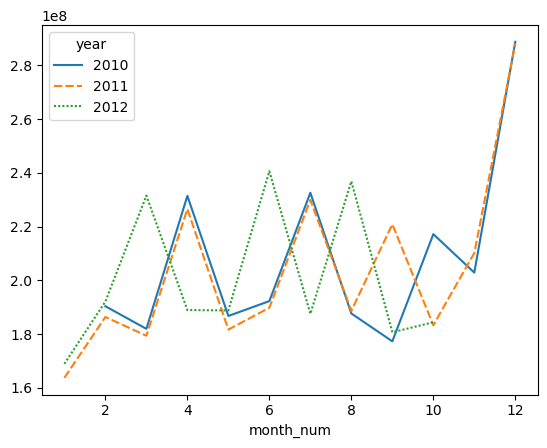

In [14]:
sns.lineplot(pivot_sales.T)

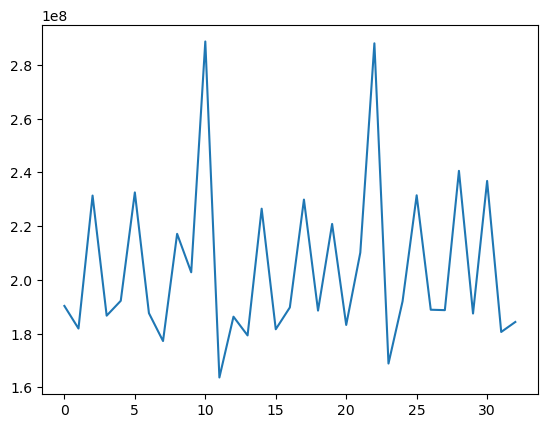

In [15]:
plt.plot(monthly_sales['total_sales'])
# sns.lineplot(, x=)

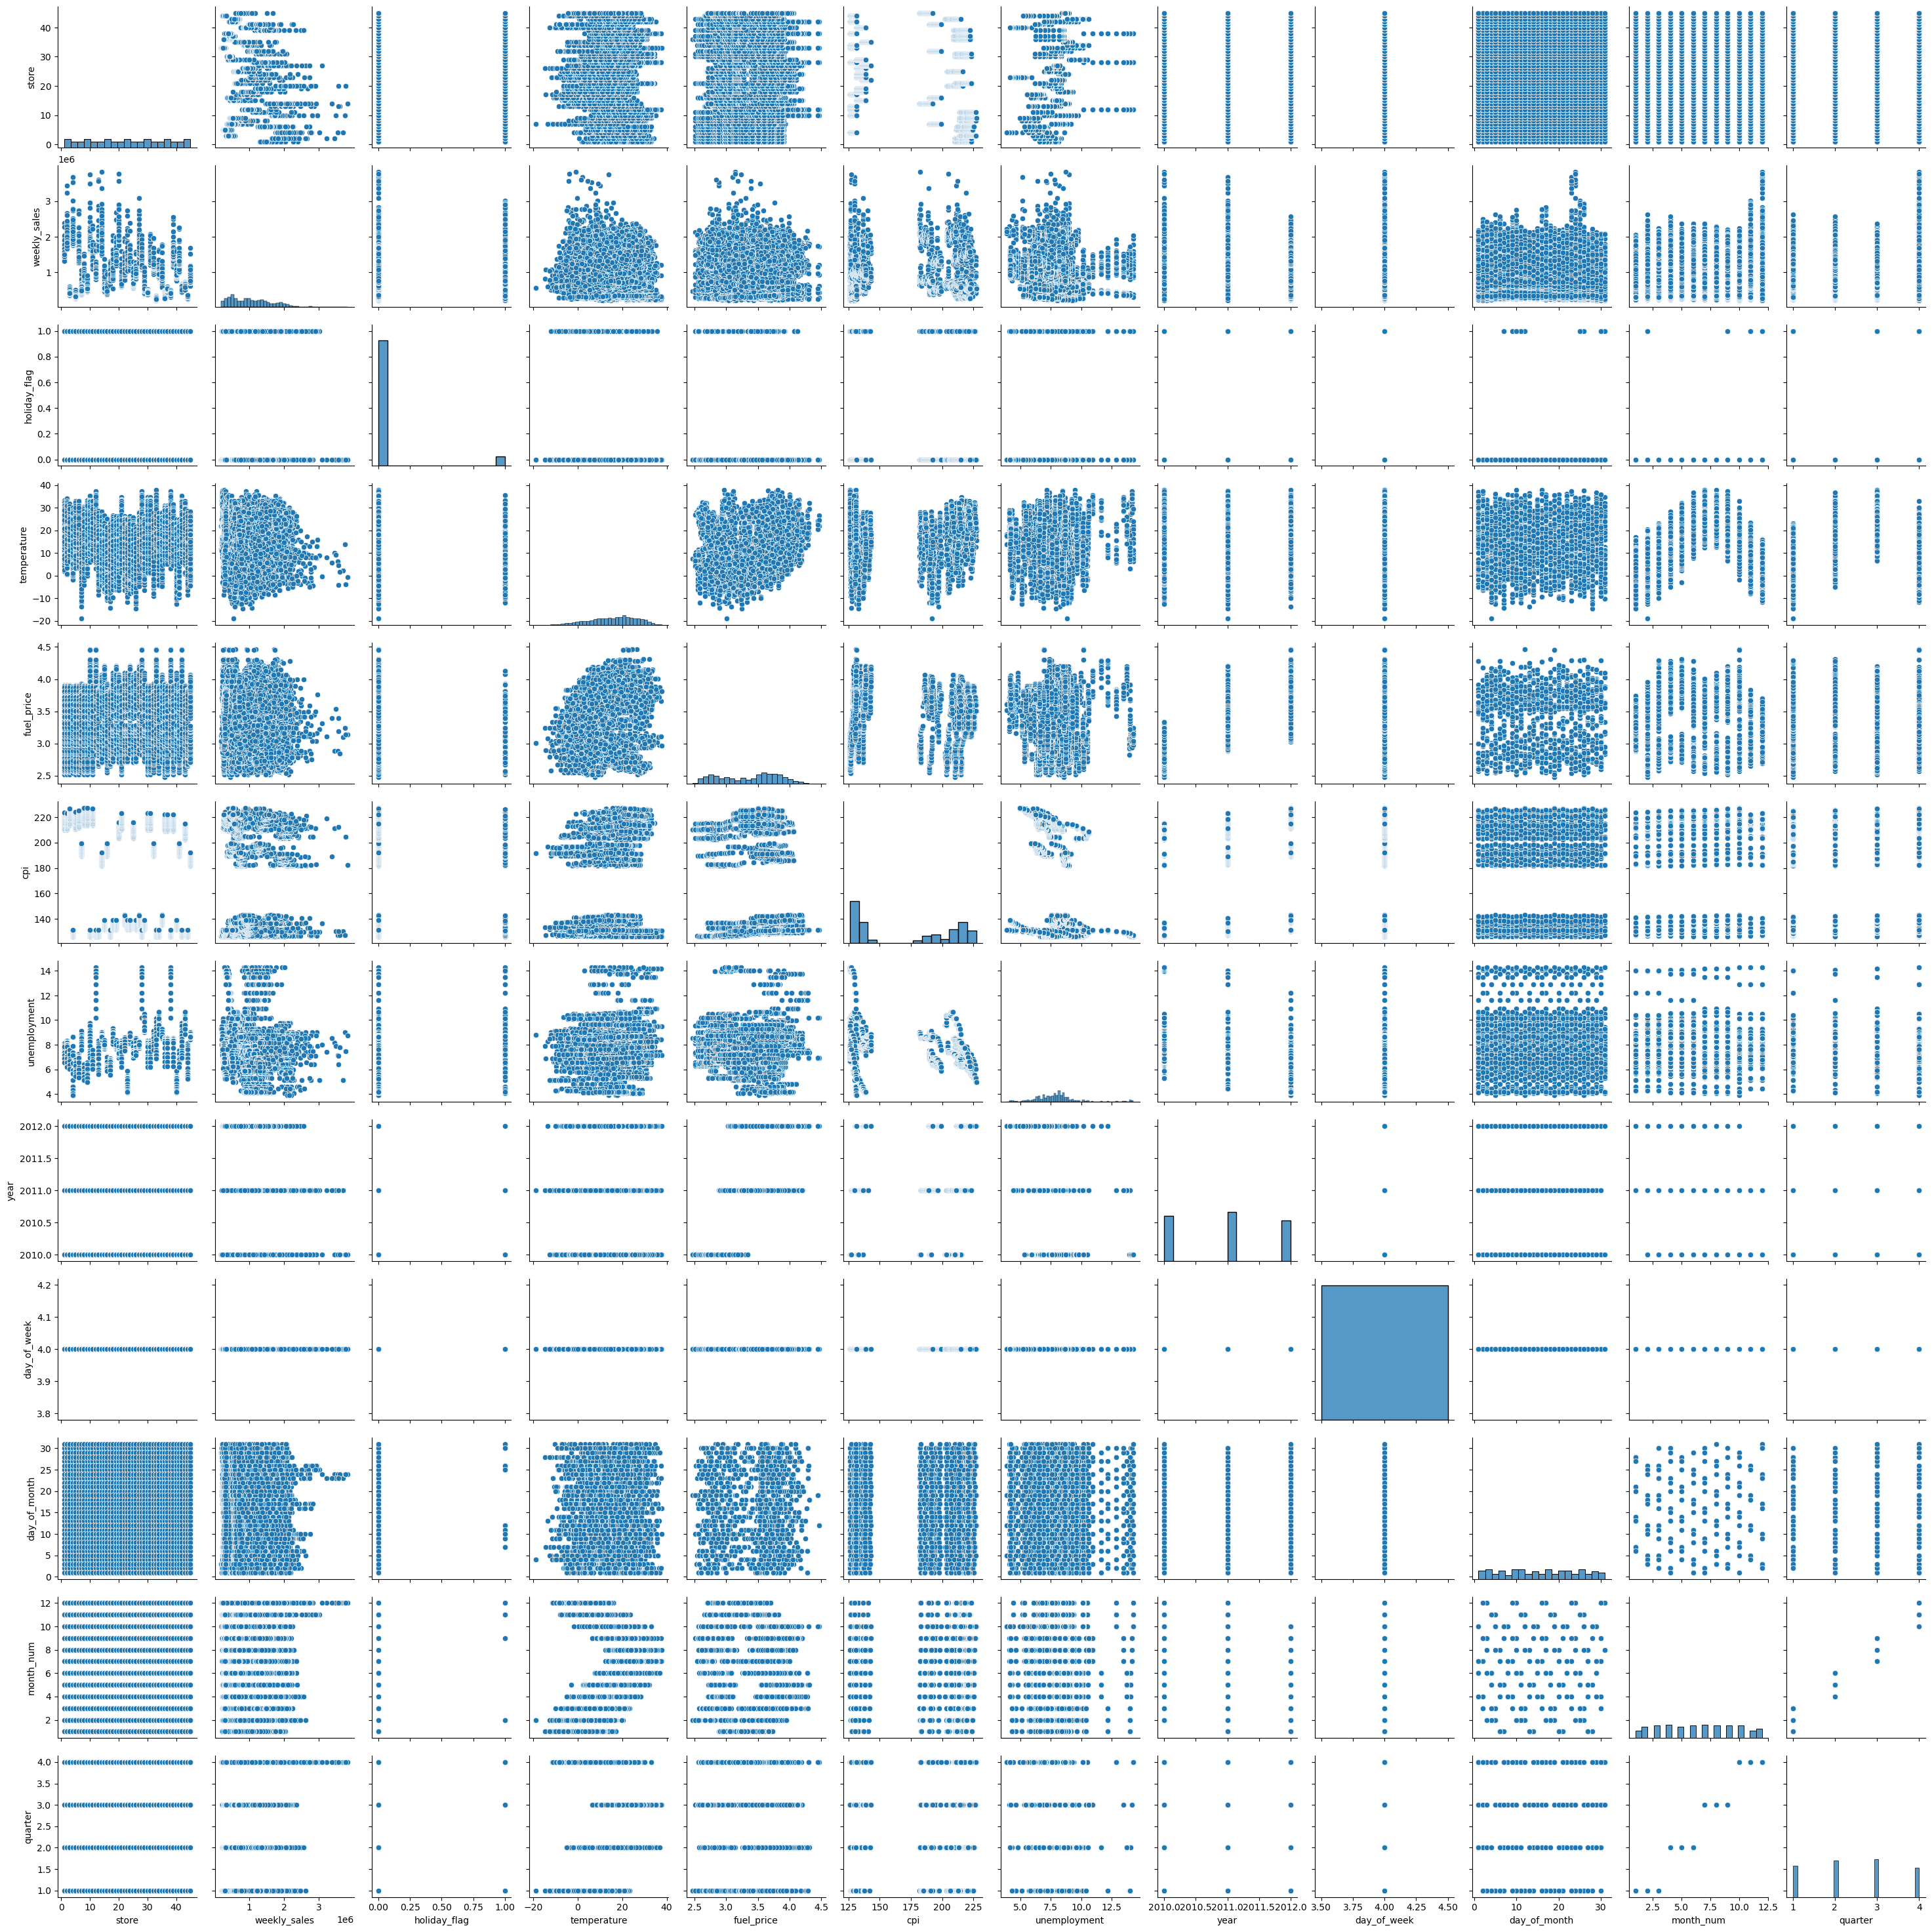

In [16]:
sns.pairplot(df)

In [17]:
from scipy import stats

In [18]:
r = stats.pearsonr(df['temperature'], df['cpi'])
r

PearsonRResult(statistic=0.17688767634228564, pvalue=2.1945139533078307e-46)

In [19]:
r.confidence_interval()

ConfidenceInterval(low=0.1531157793467519, high=0.20045497266590437)

In [20]:
rho = stats.spearmanr(df['temperature'], df['cpi'])

In [21]:
b = stats.pearsonr(df["weekly_sales"], df["temperature"])
b.confidence_interval()

ConfidenceInterval(low=-0.08810631111451891, high=-0.039437835614783666)

In [22]:
q1 = df["weekly_sales"].quantile(.25)
q3 = df["weekly_sales"].quantile(.75)

iqr = q3 - q1

lb = q1 - iqr * 1.5
ub = q3 + iqr * 1.5

df[(df["weekly_sales"] >= lb) & (df["weekly_sales"] <= ub)]

,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment,month,year,day_of_week,day_name,day_of_month,month_num,quarter,month_name
0,1,2010-02-05,1643690.90,0,5.727778,2.572,211.096358,8.106,2010-02,2010,4,Friday,5,2,1,February
1,1,2010-02-12,1641957.44,1,3.616667,2.548,211.242170,8.106,2010-02,2010,4,Friday,12,2,1,February
2,1,2010-02-19,1611968.17,0,4.405556,2.514,211.289143,8.106,2010-02,2010,4,Friday,19,2,1,February
3,1,2010-02-26,1409727.59,0,8.127778,2.561,211.319643,8.106,2010-02,2010,4,Friday,26,2,1,February
4,1,2010-03-05,1554806.68,0,8.055556,2.625,211.350143,8.106,2010-03,2010,4,Friday,5,3,1,March
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,18.266667,3.997,192.013558,8.684,2012-09,2012,4,Friday,28,9,3,September
6431,45,2012-10-05,733455.07,0,18.272222,3.985,192.170412,8.667,2012-10,2012,4,Friday,5,10,4,October
6432,45,2012-10-12,734464.36,0,12.483333,4.000,192.327265,8.667,2012-10,2012,4,Friday,12,10,4,October
6433,45,2012-10-19,718125.53,0,13.594444,3.969,192.330854,8.667,2012-10,2012,4,Friday,19,10,4,October


In [23]:
store_sale = df.groupby("store")["weekly_sales"].sum().reset_index()
store_sale.sort_values(by='weekly_sales', ascending=False).reset_index(drop=True)

,store,weekly_sales
0,20,3.013978e+08
1,4,2.995440e+08
2,14,2.889999e+08
3,13,2.865177e+08
4,2,2.753824e+08
5,10,2.716177e+08
6,27,2.538559e+08
7,6,2.237561e+08
8,1,2.224028e+08
9,39,2.074455e+08


In [24]:
month_performance = (df.groupby("month_name")["weekly_sales"].sum()).sort_values(ascending=False)
month_performance

month_name
July         6.500010e+08
April        6.468598e+08
June         6.226299e+08
August       6.130902e+08
March        5.927859e+08
October      5.847848e+08
September    5.787612e+08
December     5.768386e+08
February     5.687279e+08
May          5.571256e+08
November     4.130157e+08
January      3.325984e+08
Name: weekly_sales, dtype: float64

In [25]:
holiday_effect_on_sales = df.groupby("holiday_flag")["weekly_sales"].mean()
holiday_effect_on_sales

holiday_flag
0    1.041256e+06
1    1.122888e+06
Name: weekly_sales, dtype: float64

<Axes: xlabel='month'>

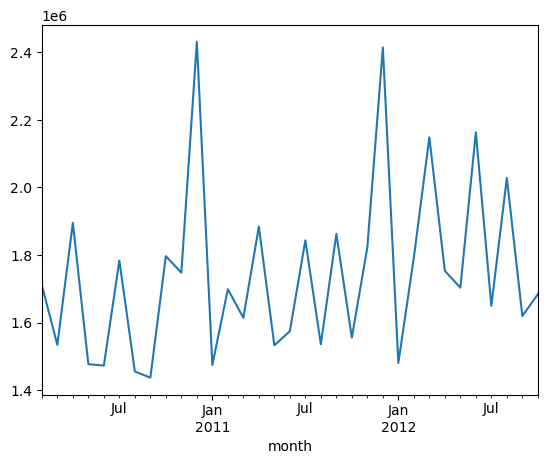

In [26]:
store1 = df[df["store"] == 3]
store1.groupby("month")["weekly_sales"].sum().plot()

In [27]:
year_sales = (df.groupby("year")["weekly_sales"].sum())
year_sales.pct_change() * 100

year
2010          NaN
2011     6.960324
2012   -18.301901
Name: weekly_sales, dtype: float64

In [28]:
month_sales = (df.groupby("month")["weekly_sales"].sum())
month_sales.pct_change() * 100

month
2010-02          NaN
2010-03    -4.420243
2010-04    27.205705
2010-05   -19.316787
2010-06     2.964603
2010-07    20.980368
2010-08   -19.322380
2010-09    -5.527717
2010-10    22.504880
2010-11    -6.588844
2010-12    42.349389
2011-01   -43.308053
2011-02    13.822121
2011-03    -3.743267
2011-04    26.299619
2011-05   -19.811523
2011-06     4.473058
2011-07    21.150497
2011-08   -17.968690
2011-09    17.098897
2011-10   -17.019171
2011-11    14.679081
2011-12    37.074074
2012-01   -41.371986
2012-02    13.718097
2012-03    20.538028
2012-04   -18.396099
2012-05    -0.081741
2012-06    27.464542
2012-07   -22.069242
2012-08    26.314041
2012-09   -23.730226
2012-10     2.057142
Freq: M, Name: weekly_sales, dtype: float64

In [29]:
store_performance = (df.groupby("store")["weekly_sales"].sum().sort_values(ascending=False))
store_performance

store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
19    2.066349e+08
31    1.996139e+08
23    1.987506e+08
24    1.940160e+08
11    1.939628e+08
28    1.892637e+08
41    1.813419e+08
32    1.668192e+08
18    1.551147e+08
22    1.470756e+08
12    1.442872e+08
26    1.434164e+08
34    1.382498e+08
40    1.378703e+08
35    1.315207e+08
8     1.299512e+08
17    1.277821e+08
45    1.123953e+08
21    1.081179e+08
25    1.010612e+08
43    9.056544e+07
15    8.913368e+07
7     8.159828e+07
42    7.956575e+07
9     7.778922e+07
29    7.714155e+07
16    7.425243e+07
37    7.420274e+07
30    6.271689e+07
3     5.758674e+07
38    5.515963e+07
36    5.341221e+07
5     4.547569e+07
44    4.329309e+07
33    3.716022e+07
Name: weekly_sales, dtype: float64

In [30]:
avg_store_sales = (df.groupby("store")["weekly_sales"].mean().sort_values(ascending=False))
avg_store_sales

store
20    2.107677e+06
4     2.094713e+06
14    2.020978e+06
13    2.003620e+06
2     1.925751e+06
10    1.899425e+06
27    1.775216e+06
6     1.564728e+06
1     1.555264e+06
39    1.450668e+06
19    1.444999e+06
31    1.395901e+06
23    1.389864e+06
24    1.356755e+06
11    1.356383e+06
28    1.323522e+06
41    1.268125e+06
32    1.166568e+06
18    1.084718e+06
22    1.028501e+06
12    1.009002e+06
26    1.002912e+06
34    9.667816e+05
40    9.641280e+05
35    9.197250e+05
8     9.087495e+05
17    8.935814e+05
45    7.859814e+05
21    7.560691e+05
25    7.067215e+05
43    6.333247e+05
15    6.233125e+05
7     5.706173e+05
42    5.564039e+05
9     5.439806e+05
29    5.394514e+05
16    5.192477e+05
37    5.189003e+05
30    4.385796e+05
3     4.027044e+05
38    3.857317e+05
36    3.735120e+05
5     3.180118e+05
44    3.027489e+05
33    2.598617e+05
Name: weekly_sales, dtype: float64

In [31]:
yearly_store_sales = (df.groupby(["store","year"])["weekly_sales"].sum().sort_values(ascending=False)).reset_index()
yearly_store_sales

,store,year,weekly_sales
0,4,2011,1.110923e+08
1,20,2011,1.098370e+08
2,14,2011,1.060963e+08
3,14,2010,1.054622e+08
4,13,2011,1.045375e+08
...,...,...,...
130,44,2010,1.360752e+07
131,36,2012,1.328647e+07
132,33,2011,1.295784e+07
133,33,2010,1.276683e+07


In [32]:
growth = yearly_store_sales.pivot(index="store", columns="year", values="weekly_sales")
growth["growth_%"] = ((growth[2012] - growth[2010]) / (growth[2010])) * 100
growth.sort_values("growth_%", ascending=False)

year,2010,2011,2012,growth_%
store,,,,
38,1.658779e+07,1.994076e+07,18631073.45,12.317966
44,1.360752e+07,1.549819e+07,14187373.72,4.261278
39,6.578228e+07,7.577760e+07,65885662.85,0.157165
7,2.556808e+07,3.066264e+07,25367556.47,-0.784266
41,5.773822e+07,6.671587e+07,56887839.93,-1.472821
17,4.110492e+07,4.639184e+07,40285378.63,-1.993780
42,2.549809e+07,2.911730e+07,24950359.85,-2.148122
4,9.568047e+07,1.110923e+08,92771189.24,-3.040622
3,1.874542e+07,2.081688e+07,18024439.50,-3.846164


In [33]:
store_stability = (df.groupby("store")["weekly_sales"].agg(mean_sales="mean", std_sales="std"))
store_stability

,mean_sales,std_sales
store,,
1,1.555264e+06,155980.767761
2,1.925751e+06,237683.694682
3,4.027044e+05,46319.631557
4,2.094713e+06,266201.442297
5,3.180118e+05,37737.965745
6,1.564728e+06,212525.855862
7,5.706173e+05,112585.469220
8,9.087495e+05,106280.829881
9,5.439806e+05,69028.666585


In [34]:
score = (df.groupby("store")["weekly_sales"].agg(total_sales="sum", avg_sales="mean", volatility="std"))
score["performance_score"] = (score["avg_sales"] / score["volatility"])
score_sorted = score.sort_values("performance_score", ascending=False)
score_sorted

,total_sales,avg_sales,volatility,performance_score
store,,,,
37,7.420274e+07,5.189003e+05,21837.461190,23.761933
30,6.271689e+07,4.385796e+05,22809.665590,19.227797
43,9.056544e+07,6.333247e+05,40598.413260,15.599741
44,4.329309e+07,3.027489e+05,24762.832015,12.225939
31,1.996139e+08,1.395901e+06,125855.942933,11.091264
42,7.956575e+07,5.564039e+05,50262.925530,11.069866
33,3.716022e+07,2.598617e+05,24132.927322,10.767931
1,2.224028e+08,1.555264e+06,155980.767761,9.970873
34,1.382498e+08,9.667816e+05,104630.164676,9.239989


In [35]:
top5 = score_sorted[:5]
bottom5 = score_sorted[-5:]

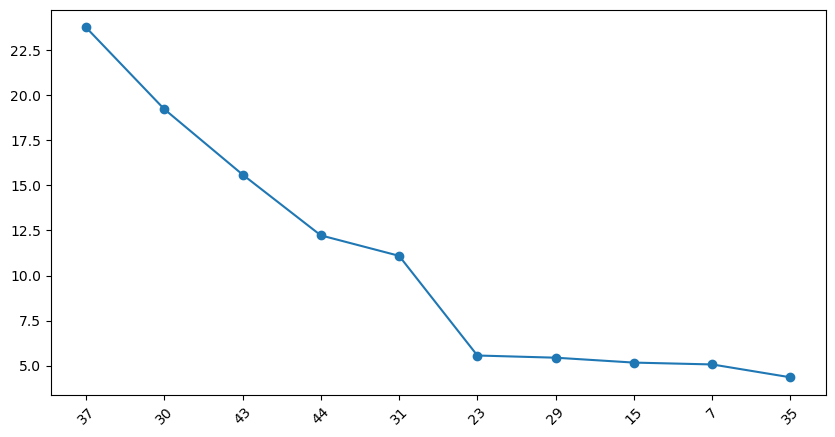

In [36]:
plot_data = pd.concat([top5, bottom5])
plt.figure(figsize=(10,5))
plt.plot(plot_data.index.astype(str), plot_data["performance_score"], marker="o")
plt.xticks(rotation=45); plt.show()